In [19]:
# Install required libraries
!pip install -q datasets

print("Student Name: Piriyadharshini N\nRoll No: 24BAD086")

# Import libraries
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from datasets import load_dataset
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

print("TensorFlow Version:", tf.__version__)

Student Name: Piriyadharshini N
Roll No: 24BAD086
TensorFlow Version: 2.20.0


In [33]:
# PART A: DATASET PREPARATION

!pip install -q datasets

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from datasets import load_dataset
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Load dataset
dataset = load_dataset("Trelis/tiny-shakespeare")

print(dataset)

# Explore dataset
text = dataset["train"][0]["Text"]

print("Total Characters:", len(text))
print(text[:1000])

# Preprocess text
text = text.lower()

# Tokenization
tokenizer = Tokenizer(
    filters='!"#$%&()*+,-./:;<=>?@[\\]^_`{|}~\t\n',
    oov_token="<OOV>"
)

tokenizer.fit_on_texts([text])

token_list = tokenizer.texts_to_sequences([text])[0]
total_words = len(tokenizer.word_index) + 1

print("Vocabulary Size:", total_words)

# Generate sequences
sequence_length = 20
input_sequences = []

for i in range(sequence_length, len(token_list)):
    sequence = token_list[i-sequence_length:i+1]
    input_sequences.append(sequence)

input_sequences = np.array(input_sequences)

# Padding
input_sequences = pad_sequences(
    input_sequences,
    maxlen=sequence_length + 1,
    padding="pre"
)

# Split input and target
X = input_sequences[:, :-1]
y = input_sequences[:, -1]

print("Input Shape:", X.shape)
print("Target Shape:", y.shape)

# Train-validation split
indices = np.arange(len(X))
np.random.shuffle(indices)

X = X[indices]
y = y[indices]

split = int(0.8 * len(X))

X_train = X[:split]
y_train = y[:split]

X_val = X[split:]
y_val = y[split:]

print("Training Samples:", len(X_train))
print("Validation Samples:", len(X_val))

# Create TensorFlow datasets
BATCH_SIZE = 128

train_dataset = tf.data.Dataset.from_tensor_slices(
    (X_train, y_train)
).shuffle(10000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

val_dataset = tf.data.Dataset.from_tensor_slices(
    (X_val, y_val)
).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

print("PART A COMPLETED")

DatasetDict({
    train: Dataset({
        features: ['Text'],
        num_rows: 472
    })
    test: Dataset({
        features: ['Text'],
        num_rows: 49
    })
})
Total Characters: 3131
First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us kill him, and we'll have corn at our own price.
Is't a verdict?

All:
No more talking on't; let it be done: away, away!

Second Citizen:
One word, good citizens.

First Citizen:
We are accounted poor citizens, the patricians good.
What authority surfeits on would relieve us: if they
would yield us but the superfluity, while it were
wholesome, we might guess they relieved us humanely;
but they think we are too dear: the leanness that
afflicts us, the object of our misery, is as an
inventory to particu

In [34]:
# PART B: IMPLEMENTING THE RNN MODEL

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense

# Model parameters
embedding_dim = 128
rnn_units = 128

# Create RNN model
model = Sequential([
    Embedding(
        input_dim=total_words,
        output_dim=embedding_dim
    ),
    SimpleRNN(rnn_units),
    Dense(
        total_words,
        activation="softmax"
    )
])

# Build the model
model.build(input_shape=(None, sequence_length))

# Compile model
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Display model
model.summary()

print("Total Parameters:", model.count_params())
print("PART B COMPLETED")

Model: "sequential_19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_19 (Embedding)        │ (None, 20, 128)        │        33,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_19 (SimpleRNN)       │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 261)            │        33,669 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 99,973 (390.52 KB)

 Trainable params: 99,973 (390.52 KB)

 Non-trainable params: 0 (0.00 B)

Total Parameters: 99973
PART B COMPLETED


Student Roll No: YOUR_ROLL_NO
Training using Adam...
Epoch 1/5
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 128ms/step - accuracy: 0.0047 - loss: 5.5632 - val_accuracy: 0.0000e+00 - val_loss: 5.5723
Epoch 2/5
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.0771 - loss: 5.3944 - val_accuracy: 0.0187 - val_loss: 5.5752
Epoch 3/5
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.0701 - loss: 5.2423 - val_accuracy: 0.0187 - val_loss: 5.5486
Epoch 4/5
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 0.1215 - loss: 5.0812 - val_accuracy: 0.0187 - val_loss: 5.5450
Epoch 5/5
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.1262 - loss: 4.9084 - val_accuracy: 0.0093 - val_loss: 5.5452
Training using RMSprop...
Epoch 1/3
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 114ms/step - accuracy: 0.0000e+00 - loss: 5.5639 - val_accuracy: 0.0093 - val_loss: 5.5342
Epoch 2/3
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.1028 - loss: 5.3345 - val_accuracy: 0.0374 - val_loss: 5.5047
Epoch 3/3
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/

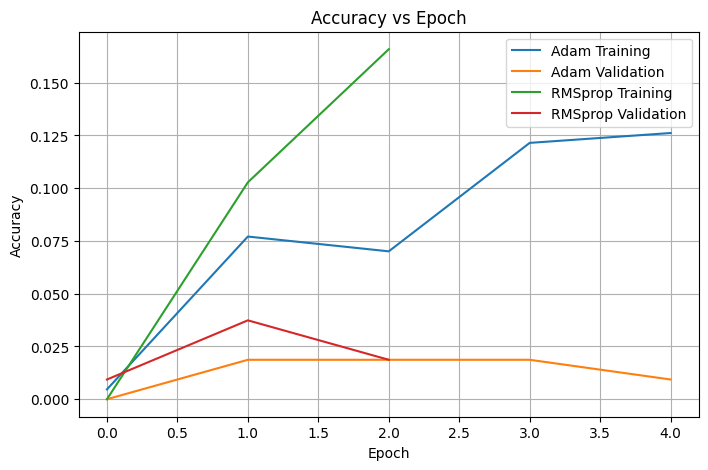

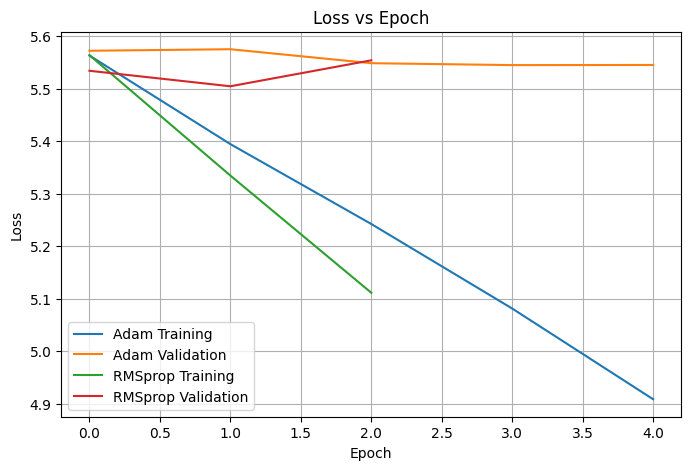

PART C COMPLETED


In [35]:
# PART C: COMPARISON OF OPTIMIZATION ALGORITHMS

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense

ROLL_NO = "YOUR_ROLL_NO"
print("Student Roll No:", ROLL_NO)

# Create model function
def create_rnn_model():
    model = Sequential([
        Embedding(
            input_dim=total_words,
            output_dim=128
        ),
        SimpleRNN(128),
        Dense(
            total_words,
            activation="softmax"
        )
    ])
    return model

# Adam optimizer
print("Training using Adam...")

adam_model = create_rnn_model()

adam_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_adam = adam_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=5
)

# RMSprop optimizer
print("Training using RMSprop...")

rmsprop_model = create_rnn_model()

rmsprop_model.compile(
    optimizer="rmsprop",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_rmsprop = rmsprop_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=3
)

# Results
adam_train_accuracy = history_adam.history["accuracy"][-1]
adam_val_accuracy = history_adam.history["val_accuracy"][-1]
adam_train_loss = history_adam.history["loss"][-1]
adam_val_loss = history_adam.history["val_loss"][-1]

rms_train_accuracy = history_rmsprop.history["accuracy"][-1]
rms_val_accuracy = history_rmsprop.history["val_accuracy"][-1]
rms_train_loss = history_rmsprop.history["loss"][-1]
rms_val_loss = history_rmsprop.history["val_loss"][-1]

print("\nADAM")
print("Training Accuracy:", adam_train_accuracy)
print("Validation Accuracy:", adam_val_accuracy)
print("Training Loss:", adam_train_loss)
print("Validation Loss:", adam_val_loss)

print("\nRMSPROP")
print("Training Accuracy:", rms_train_accuracy)
print("Validation Accuracy:", rms_val_accuracy)
print("Training Loss:", rms_train_loss)
print("Validation Loss:", rms_val_loss)

# Accuracy graph
plt.figure(figsize=(8, 5))

plt.plot(
    history_adam.history["accuracy"],
    label="Adam Training"
)

plt.plot(
    history_adam.history["val_accuracy"],
    label="Adam Validation"
)

plt.plot(
    history_rmsprop.history["accuracy"],
    label="RMSprop Training"
)

plt.plot(
    history_rmsprop.history["val_accuracy"],
    label="RMSprop Validation"
)

plt.title("Accuracy vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()

plt.show()

# Loss graph
plt.figure(figsize=(8, 5))

plt.plot(
    history_adam.history["loss"],
    label="Adam Training"
)

plt.plot(
    history_adam.history["val_loss"],
    label="Adam Validation"
)

plt.plot(
    history_rmsprop.history["loss"],
    label="RMSprop Training"
)

plt.plot(
    history_rmsprop.history["val_loss"],
    label="RMSprop Validation"
)

plt.title("Loss vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid()

plt.show()

print("PART C COMPLETED")

In [31]:
# PART D: TEXT GENERATION

import numpy as np
from tensorflow.keras.preprocessing.sequence import pad_sequences


model = adam_model

# Predict next word
def predict_next_word(seed_text):

    seed_text = seed_text.lower()

    token_list = tokenizer.texts_to_sequences(
        [seed_text]
    )[0]

    token_list = token_list[-sequence_length:]

    token_list = pad_sequences(
        [token_list],
        maxlen=sequence_length,
        padding="pre"
    )

    prediction = model.predict(
        token_list,
        verbose=0
    )

    predicted_index = np.argmax(
        prediction,
        axis=-1
    )[0]

    for word, index in tokenizer.word_index.items():
        if index == predicted_index:
            return word

    return ""

# Generate text
def generate_text(seed_text, next_words=30):

    generated_text = seed_text

    for _ in range(next_words):

        next_word = predict_next_word(
            generated_text
        )

        if next_word == "":
            break

        generated_text += " " + next_word

    return generated_text

# Generate samples
seed_inputs = [
    "to be or not to be",
    "the king",
    "my lord",
    "what is love",
    "fair lady"
]

for seed in seed_inputs:

    generated_text = generate_text(
        seed,
        next_words=30
    )

    print("=" * 70)
    print("Seed:", seed)
    print("Generated Text:")
    print(generated_text)

# Save model
model.save("rnn_text_generation_model.keras")

print("Model saved successfully")
print("PART D COMPLETED")

Seed: to be or not to be
Generated Text:
to be or not to be the king of york and all the king of york and all the king of york and all the king of york and all the king of york and all
Seed: the king
Generated Text:
the king of york and all the king of york and all the king of york and all the king of york and all the king of york and all the king
Seed: my lord
Generated Text:
my lord which is the world of the time is the king and he of the time of the time of the time of the time of the time of the time
Seed: what is love
Generated Text:
what is love and to the king of york the rest of the king and the king henry vi my lord i will not be the king of york and all the king
Seed: fair lady
Generated Text:
fair lady anne thou art not to be the king of york and my lord king richard iii what is my lord i am not to the duke of york i am
Model saved successfully
PART D COMPLETED
